<a href="https://colab.research.google.com/github/komal-shahzada/python/blob/main/mistake_free_fyp_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# CELL 1: DEPENDENCY INSTALLATION
# ==========================================
# Install required libraries for audio processing, deep learning, and API operations
!pip install librosa numpy pandas tensorflow scikit-learn groq gradio matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 7.9 MB/s eta 0:00:00


In [2]:
# ==========================================
# CELL 2: DATASET INGESTION CONFIGURATION
# ==========================================
import os
from google.colab import files

print("Please upload your 'kaggle.json' credential file below:")
# Trigger the file upload widget for Kaggle credentials
files.upload()

# Configure secure directories for Kaggle API authentication token
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download public speech emotion recognition datasets directly into the runtime
print("\nDownloading CREMA-D and TESS datasets...")
!kaggle datasets download -d dmitrybabko/speech-emotion-recognition-en
!kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess

# Extract zipped archives quietly into the root directory
print("Extracting dataset files...")
!unzip -q speech-emotion-recognition-en.zip
!unzip -q toronto-emotional-speech-set-tess.zip
print("Data ingestion pipeline complete.")

Please upload your 'kaggle.json' credential file below:


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/dmitrybabko/speech-emotion-recognition-en
License(s): copyright-authors
100% 987M/987M [00:24<00:00, 42.2MB/s]

Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 428M/428M [00:10<00:00, 41.1MB/s]

Extracting dataset files...
Data ingestion pipeline complete.


In [3]:
# ==========================================
# CELL 3: DATA PRE-PROCESSING & MASTER DATAFRAME
# ==========================================
import os
import pandas as pd

paths = []
labels = []

# 1. Parsing the Toronto Emotional Speech Set (TESS) Dataset
tess_path = '/content/tess toronto emotional speech set data/'
if os.path.exists(tess_path):
    for root, dirs, files in os.walk(tess_path):
        for file in files:
            if file.endswith('.wav'):
                # Extract the standardized emotion suffix from folder structural names
                label = root.split('_')[-1].lower()
                paths.append(os.path.join(root, file))
                labels.append(label)

# 2. Parsing the CREMA-D Dataset
crema_path = '/content/Crema/'
if os.path.exists(crema_path):
    for file in os.listdir(crema_path):
        if file.endswith('.wav'):
            # Segment the filename components using structural underscores
            parts = file.split('_')
            if parts[2] == 'ANG': labels.append('angry')
            elif parts[2] == 'SAD': labels.append('sad')
            elif parts[2] == 'HAP': labels.append('happy')
            elif parts[2] == 'NEU': labels.append('neutral')
            elif parts[2] == 'FEA': labels.append('fear')
            elif parts[2] == 'DIS': labels.append('disgust')
            else: labels.append('surprise')
            paths.append(os.path.join(crema_path, file))

# Construct a unified master dataframe containing the curated mapping configurations
master_df = pd.DataFrame({'path': paths, 'label': labels})
master_df = master_df[master_df['label'] != 'data'] # Sanitize erroneous path components

print(f"Total Unique Audio Samples Processed: {len(master_df)}")
print("\nClass Distribution Across the Combined Corpus:")
print(master_df['label'].value_counts())

Total Unique Audio Samples Processed: 10242

Class Distribution Across the Combined Corpus:
label
fear         1671
disgust      1671
angry        1671
sad          1671
happy        1671
neutral      1487
surprise      200
surprised     200
Name: count, dtype: int64


In [4]:
# ==========================================
# CELL 4: STRATIFIED DATASET SEPARATION
# ==========================================
from sklearn.model_selection import train_test_split

# Split paths first into 80% train and 20% test using stratification to balance classes
df_train, df_test = train_test_split(
    master_df,
    test_size=0.2,
    random_state=42,
    stratify=master_df['label']
)

print(f"Base Training Sub-population: {len(df_train)} elements.")
print(f"Isolated Testing Sub-population (Clean/Unseen): {len(df_test)} elements.")

Base Training Sub-population: 8193 elements.
Isolated Testing Sub-population (Clean/Unseen): 2049 elements.


In [5]:
# ==========================================
# CELL 5: ACOUSTIC FEATURE ENGINEERING & DATA AUGMENTATION
# ==========================================
import librosa
import numpy as np
from tqdm import tqdm

def extract_features(file_path, augment=False):
    try:
        # Standardize clip loading duration to 3 seconds with a baseline offset
        data, sr = librosa.load(file_path, duration=3, offset=0.5)

        # Inject controlled Gaussian White Noise strictly into the training pipeline
        if augment:
            noise = np.random.randn(len(data))
            data = data + 0.005 * noise

        # Compute 40 Mel-Frequency Cepstral Coefficients (MFCCs)
        mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)
        return mfccs
    except Exception as e:
        return None

# --- Extracting Features from Training Set (Original + Augmented Data) ---
print("Extracting acoustic vectors from TRAINING data...")
X_train_list, y_train_list = [], []

for i in tqdm(range(len(df_train))):
    path = df_train['path'].iloc[i]
    label = df_train['label'].iloc[i]

    # Process standard feature vector
    res_orig = extract_features(path, augment=False)
    if res_orig is not None:
        X_train_list.append(res_orig)
        y_train_list.append(label)

    # Generate synthetic variant for dataset expansion and regularization variance
    res_aug = extract_features(path, augment=True)
    if res_aug is not None:
        X_train_list.append(res_aug)
        y_train_list.append(label)

# --- Extracting Features from Testing Set (Strictly Clean Data) ---
print("\nExtracting acoustic vectors from TESTING data (No Augmentation Applied)...")
X_test_list, y_test_list = [], []

for i in tqdm(range(len(df_test))):
    path = df_test['path'].iloc[i]
    label = df_test['label'].iloc[i]

    res_test = extract_features(path, augment=False)
    if res_test is not None:
        X_test_list.append(res_test)
        y_test_list.append(label)

# Cast arrays into uniform structure matrices
X_train, y_train = np.array(X_train_list), np.array(y_train_list)
X_test, y_test = np.array(X_test_list), np.array(y_test_list)

print(f"\nFeature processing sequence complete.")
print(f"Training matrices dimensions (Expanded): {X_train.shape}")
print(f"Testing matrices dimensions (Standardized): {X_test.shape}")

Extracting acoustic vectors from TRAINING data...


100%|██████████| 8193/8193 [03:42<00:00, 36.87it/s]



Extracting acoustic vectors from TESTING data (No Augmentation Applied)...


100%|██████████| 2049/2049 [00:23<00:00, 85.88it/s] 


Feature processing sequence complete.
Training matrices dimensions (Expanded): (16386, 40)
Testing matrices dimensions (Standardized): (2049, 40)


In [7]:
# ==========================================
# CELL 6: CORE MODEL SYNTHESIS & PIPELINE TRAINING
# ==========================================
# EXTRA STEP: SERIALIZING EXTRACTED FEATURES TO DISK
# ==========================================
import pickle

# Save the processed numpy arrays so you NEVER have to run Cell 5 again
with open('X_train.pickle', 'wb') as f: pickle.dump(X_train, f)
with open('X_test.pickle', 'wb') as f: pickle.dump(X_test, f)
with open('y_train.pickle', 'wb') as f: pickle.dump(y_train, f)
with open('y_test.pickle', 'wb') as f: pickle.dump(y_test, f)

print("🎯 SUCCESS: All acoustic features saved to disk! Download these .pickle files to your computer for backup.")
# ==========================================
# EXTRA STEP: SERIALIZING EXTRACTED FEATURES TO DISK
# ==========================================
import pickle

# Save the processed numpy arrays so you NEVER have to run Cell 5 again
with open('X_train.pickle', 'wb') as f: pickle.dump(X_train, f)
with open('X_test.pickle', 'wb') as f: pickle.dump(X_test, f)
with open('y_train.pickle', 'wb') as f: pickle.dump(y_train, f)
with open('y_test.pickle', 'wb') as f: pickle.dump(y_test, f)

print("🎯 SUCCESS: All acoustic features saved to disk! Download these .pickle files to your computer for backup.")
# ==========================================
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pickle

# Encode multi-class labels to structural categorical representations
label_encoder = LabelEncoder()
y_train_encoded = to_categorical(label_encoder.fit_transform(y_train))
y_test_encoded = to_categorical(label_encoder.transform(y_test))

# Standardize acoustic arrays via scaling factors based exclusively on training metrics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape raw feature metrics to comply with Conv1D computational dimensional maps
X_train_reshaped = np.expand_dims(X_train_scaled, axis=2)
X_test_reshaped = np.expand_dims(X_test_scaled, axis=2)

# Instantiate the Hybrid CNN-LSTM Model Topology
model = models.Sequential([
    # CNN Spatial Layer Block
    layers.Conv1D(512, 8, padding='same', activation='relu', input_shape=(40, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=5, strides=2, padding='same'),
    layers.Dropout(0.3),

    layers.Conv1D(256, 8, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=5, strides=2, padding='same'),
    layers.Dropout(0.3),

    # LSTM Temporal Recurrent Block
    layers.LSTM(128, return_sequences=True),
    layers.LSTM(64),
    layers.Dropout(0.4),

    # Dense Classification Framework
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Define structural heuristics optimization callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

print("\nBeginning training routine across the dynamic spatial-temporal parameters...")
history = model.fit(
    X_train_reshaped, y_train_encoded,
    validation_data=(X_test_reshaped, y_test_encoded),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr]
)

# Export assets to disk
model.save('emotion_model.h5')
with open('label_encoder.pickle', 'wb') as f: pickle.dump(label_encoder, f)
with open('scaler.pickle', 'wb') as f: pickle.dump(scaler, f)
print("\nAll trained parameters and deployment assets have been securely serialized.")

🎯 SUCCESS: All acoustic features saved to disk! Download these .pickle files to your computer for backup.
🎯 SUCCESS: All acoustic features saved to disk! Download these .pickle files to your computer for backup.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 40, 512)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 20, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 20, 256)        │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,307,976 (4.99 MB)

 Trainable params: 1,306,312 (4.98 MB)

 Non-trainable params: 1,664 (6.50 KB)


Beginning training routine across the dynamic spatial-temporal parameters...
Epoch 1/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.4276 - loss: 2.0060 - val_accuracy: 0.3006 - val_loss: 2.0998 - learning_rate: 0.0010
Epoch 2/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.5179 - loss: 1.4571 - val_accuracy: 0.4763 - val_loss: 1.4419 - learning_rate: 0.0010
Epoch 3/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5433 - loss: 1.2686 - val_accuracy: 0.5183 - val_loss: 1.2471 - learning_rate: 0.0010
Epoch 4/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5580 - loss: 1.1704 - val_accuracy: 0.5437 - val_loss: 1.1880 - learning_rate: 0.0010
Epoch 5/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5685 - loss: 1.1198 - val_accuracy: 0.5505 - val_loss: 1.1750 - learning_rate: 0.0010
Epoch 6/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5652 - loss: 1.1232 - val_accuracy: 0.5525 - val_loss: 1.1250 - learning_rate: 0.00


All trained parameters and deployment assets have been securely serialized.


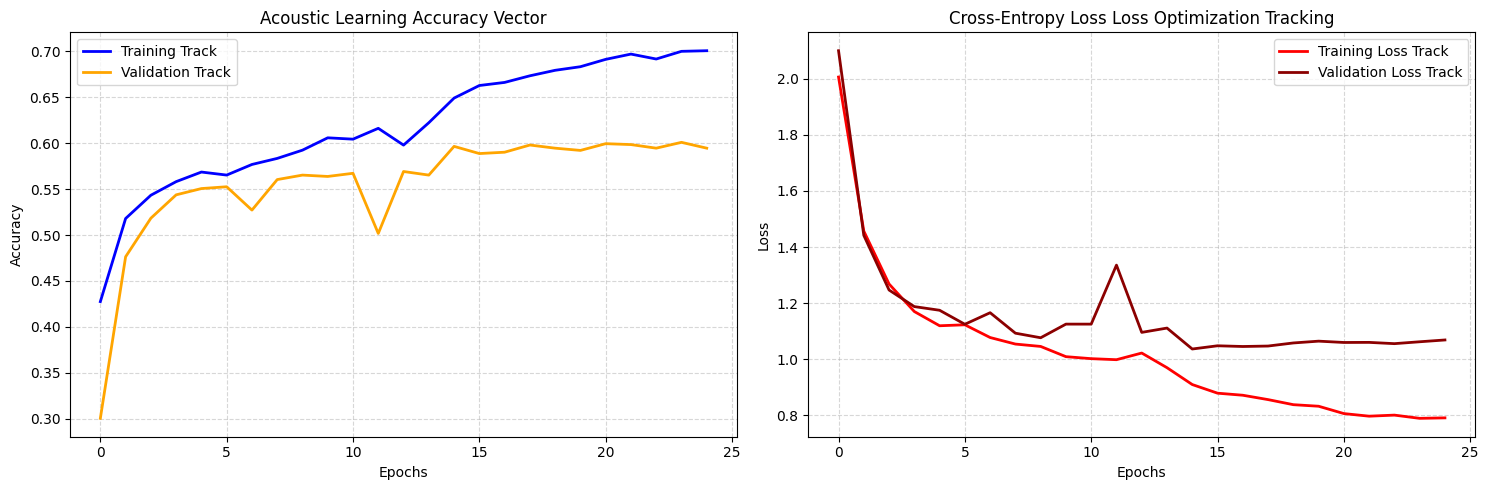

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

================== DETAILED CLASSIFICATION REPORT ==================
              precision    recall  f1-score   support

       angry       0.69      0.69      0.69       334
     disgust       0.55      0.48      0.51       334
        fear       0.62      0.47      0.53       334
       happy       0.53      0.50      0.52       335
     neutral       0.51      0.58      0.55       298
         sad       0.58      0.75      0.65       334
    surprise       0.95      1.00      0.98        40
   surprised       1.00      1.00      1.00        40

    accuracy                           0.60      2049
   macro avg       0.68      0.69      0.68      2049
weighted avg       0.60      0.60      0.59      2049



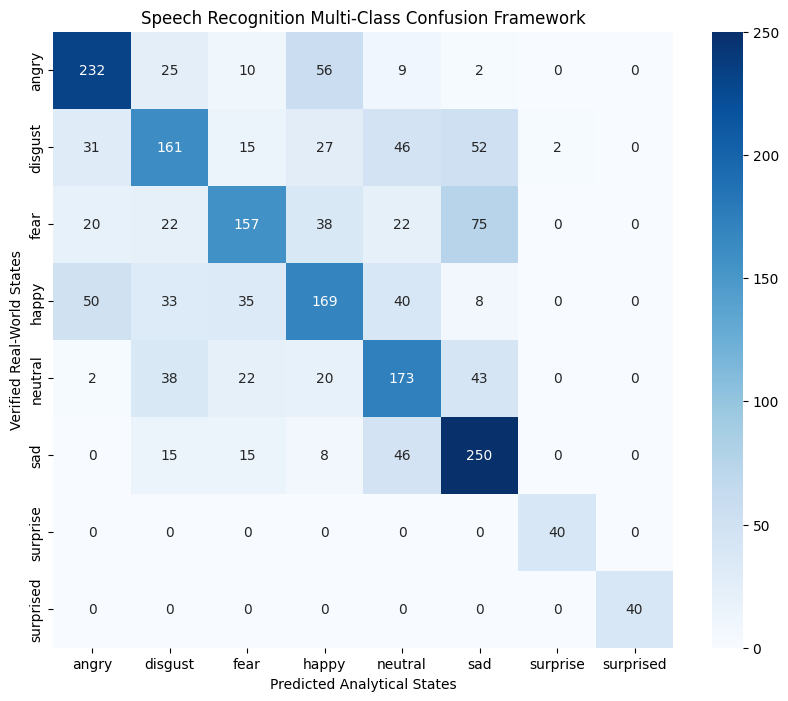

In [8]:
# ==========================================
# CELL 7: DIAGNOSTIC PLOTS & ACCURACY EVALUATION
# ==========================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Generate metric tracking dataframes over runtime iterations
plt.figure(figsize=(15, 5))

# Plot accuracy behavior across discrete iterations
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Track', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Track', color='orange', linewidth=2)
plt.title('Acoustic Learning Accuracy Vector')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Plot loss curves behavior across discrete iterations
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss Track', color='red', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss Track', color='darkred', linewidth=2)
plt.title('Cross-Entropy Loss Loss Optimization Tracking')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Perform standard matrix forward execution inferences
y_pred = model.predict(X_test_reshaped)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test_encoded, axis=1)

print("\n================== DETAILED CLASSIFICATION REPORT ==================")
print(classification_report(y_true_labels, y_pred_labels, target_names=label_encoder.classes_))

# Construct Graphical Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Speech Recognition Multi-Class Confusion Framework')
plt.xlabel('Predicted Analytical States')
plt.ylabel('Verified Real-World States')
plt.show()

In [9]:
# ==========================================
# CELL 8: DEPLOYMENT READY INFRASTRUCTURE VERIFICATION
# ==========================================
import os

required_artifacts = ['emotion_model.h5', 'label_encoder.pickle', 'scaler.pickle']
all_validated = True

print("Checking operational status of structural model components:")
for asset in required_artifacts:
    if os.path.exists(asset):
        print(f"✅ Active System Asset Located: {asset}")
    else:
        print(f"❌ Missing Core Core Artifact: {asset}")
        all_validated = False

if all_validated:
    print("\nInfrastructure validation status: Ready for full front-end execution module! 🚀")
else:
    print("\nWarning: System parts missing. Re-execute the cell sequences.")

Checking operational status of structural model components:
✅ Active System Asset Located: emotion_model.h5
✅ Active System Asset Located: label_encoder.pickle
✅ Active System Asset Located: scaler.pickle

Infrastructure validation status: Ready for full front-end execution module! 🚀


In [ ]:
# ==========================================
# CELL 9: GRADIO FRONT-END INTERFACE & SECURE AI ROUTINE
# ==========================================
import gradio as gr
import librosa
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from groq import Groq
from google.colab import userdata

# Load deep learning models and transformation objects
inference_model = load_model('emotion_model.h5')

with open('label_encoder.pickle', 'rb') as f:
    target_labels = pickle.load(f)

with open('scaler.pickle', 'rb') as f:
    feature_scaler = pickle.load(f)

# Initialize secure Groq infrastructure via Colab environment tokens
try:
    token_key = userdata.get('GROQ_API_KEY')
    groq_client = Groq(api_key=token_key)
except Exception as e:
    print(f"Operational Advisory: GROQ_API_KEY could not be extracted via system parameters. Error: {e}")
    groq_client = None

def chat_with_bot(message, history):
    if groq_client is None:
        return "Internal Exception: System environment key variable could not be resolved cleanly."
    try:
        completion = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "system", "content": "You are a Forensic Speech Analysis assistant for VoxForensics."},
                {"role": "user", "content": message}
            ],
            temperature=0.7,
        )
        return completion.choices[0].message.content
    except Exception as e:
        return f"Operational API processing halt encountered: {str(e)}"

def live_prediction(audio_path):
    try:
        if audio_path is None:
            return "Acoustic System Alert: Empty audio vector passed.", None

        # Standardize real-time input sound files parameters
        data, sr = librosa.load(audio_path, duration=3, offset=0.5)
        mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)

        # Apply normalization transformation parameters tracking baseline metadata metrics
        mfccs_scaled = feature_scaler.transform(mfccs.reshape(1, -1))
        mfccs_final = np.expand_dims(mfccs_scaled, axis=2)

        # Process structural network output probabilities
        predictions = inference_model.predict(mfccs_final)[0]
        confidences = {target_labels.classes_[i]: float(predictions[i]) for i in range(len(target_labels.classes_))}
        top_emotion = target_labels.classes_[np.argmax(predictions)].upper()

        return f"PRIMARY SYSTEM DETECTION: {top_emotion}", confidences
    except Exception as e:
        return f"Structural Core Parsing Failure: {str(e)}", None

# Build the modular theme front-end workspace environment
with gr.Blocks(theme=gr.themes.Soft(primary_hue="cyan", secondary_hue="blue")) as demo:
    gr.Markdown("# 🎙️ **VoxForensics: Forensic Speech Analysis System**")
    gr.Markdown("Developed by: **Komal Shahzada** | Final Year Project - Computer Science")

    with gr.Tabs():
        # TAB 1: RUNTIME FORENSIC INFERENCE
        with gr.TabItem("🔍 Live Analysis Portal"):
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### **Step 1: Input Console**")
                    audio_input = gr.Audio(type="filepath", label="Record or Upload Audio Sample")
                    predict_btn = gr.Button("RUN FORENSIC SCAN", variant="primary")
                with gr.Column():
                    gr.Markdown("### **Step 2: Probability Distribution**")
                    output_summary = gr.Textbox(label="Top Prediction Result", interactive=False)
                    output_label = gr.Label(num_top_classes=len(target_labels.classes_), label="Emotion Confidence Levels")
            predict_btn.click(fn=live_prediction, inputs=audio_input, outputs=[output_summary, output_label])

        # TAB 2: AI ASSISTED CHAT INTERACTION
        with gr.TabItem("🤖 Forensic AI Consultant"):
            gr.ChatInterface(fn=chat_with_bot)

        # TAB 3: ALIGNED ARCHITECTURAL PAPER DOCUMENTATION
        with gr.TabItem("📖 Project Documentation"):
            gr.Markdown("""
            # **VoxForensics: The Science Behind the System**

            ### **1. Executive Summary**
            VoxForensics is an advanced **Speech Emotion Recognition (SER)** processing infrastructure engineered to facilitate deep forensic profiling. By extracting short-term acoustic wave patterns, the system matches vocal variables to core psychological states.

            ### **2. Analytical Engine Architecture & Methods**
            The design of this system relies on a clean, end-to-end technical approach:
            * **Corpus Ingestion:** Leveraged the standardized **CREMA-D** and **TESS** datasets to secure diverse, variable acoustic parameters across age groups and genders.
            * **Acoustic Transform:** Extracted 40 distinct **MFCC (Mel-Frequency Cepstral Coefficients)** paths to mathematically map complex vocal vectors.
            * **Neural Infrastructure:** A **Hybrid CNN-LSTM** pipeline. The spatial dimensional networks (**CNN**) segment structural timbre configurations, while the sequential networks (**LSTM**) parse longitudinal timing properties.

            ### **3. Overfitting Prevention & Reliability Metrics**
            To handle real-world audio interference, the deployment framework incorporates structural **L2 Regularization**, targeted layer **Dropout (0.4)** parameters, and robust multi-level **Batch Normalization** modules.
            """)

        # TAB 4: RESEARCH FELLOW PORTFOLIO
        with gr.TabItem("👩‍💻 Researcher Profile"):
            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown(f"""
                    # **Komal Shahzada**
                    *Computer Scientist & AI Researcher*

                    **Education:**
                    * **BS Computer Science** (Final Year)
                    * **Institution:** Government Graduate College Burewala
                    * **CGPA:** **3.74 / 4.00**
                    * **Academic Distinction:** Student of the Year (2025)

                    **Professional Registries:**
                    * 🌐 [LinkedIn](https://www.linkedin.com/in/komal-shahzada)
                    * 📂 [GitHub](https://github.com/komal-shahzada)
                    """)

                with gr.Column(scale=2):
                    gr.Markdown("""
                    ### **🚀 Excellence in AI & Engineering**
                    * **HEC & Pak Angels:** Completed advanced **Generative AI Training** (Cohort 3).
                    * **Honhaar Jawan Program:** Specialized tracks in **AWS Machine Learning** and **Data Analytics**.
                    * **Certifications:** Professional credentials from Google and Coursera in Data Modeling and Core AI Fundamentals.

                    ### **💼 Industrial Engineering Exposure**
                    * **SyntecXHub:** Developed enterprise machine learning pipelines for Customer Clustering and Fraud Ingestion patterns.
                    * **CodeAlpha:** Engineered dynamic deep learning architectures for Risk Scoring and Health Profiling.

                    ### **🛠️ Technical Core Competencies**
                    Python Software Architecture, TensorFlow Frameworks, Hybrid CNN-LSTM Processing, Feature Extraction (Librosa), UI Engineering (Gradio).
                    """)

# Execute front-end components inside the environment
demo.launch(share=True, debug=True)

/tmp/ipykernel_1432/741907305.py:68: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="cyan", secondary_hue="blue")) as demo:
/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f1c67646db4609fbeb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


/tmp/ipykernel_1432/741907305.py:51: UserWarning: PySoundFile failed. Trying audioread instead.
  data, sr = librosa.load(audio_path, duration=3, offset=0.5)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/tmp/ipykernel_1432/741907305.py:51: UserWarning: PySoundFile failed. Trying audioread instead.
  data, sr = librosa.load(audio_path, duration=3, offset=0.5)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
